In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("../data/fake-currency-preprocessed.csv")
print(df.shape)
df.head()

(1000000, 16)


,Counterfeit,Weight,Length,Width,Thickness,amount,Country_EU,Country_UK,Country_USA,SecurityFeatures_Hologram,SecurityFeatures_Microprint,SecurityFeatures_Security Thread,SecurityFeatures_Watermark,currency_name_dollar,currency_name_euro,currency_name_pound
0,1,1.731759,130.243185,66.537999,0.098488,100,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,1.002179,152.596364,76.135834,0.094119,20,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0,2.306713,152.857126,66.772442,0.061393,10,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,1.366965,143.133672,78.377052,0.053114,20,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1,1.796075,129.664777,75.916093,0.051438,20,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   Counterfeit                       1000000 non-null  int64  
 1   Weight                            1000000 non-null  float64
 2   Length                            1000000 non-null  float64
 3   Width                             1000000 non-null  float64
 4   Thickness                         1000000 non-null  float64
 5   amount                            1000000 non-null  int64  
 6   Country_EU                        1000000 non-null  float64
 7   Country_UK                        1000000 non-null  float64
 8   Country_USA                       1000000 non-null  float64
 9   SecurityFeatures_Hologram         1000000 non-null  float64
 10  SecurityFeatures_Microprint       1000000 non-null  float64
 11  SecurityFeatures_Security Thread  1000000 non-nul

,Counterfeit,Weight,Length,Width,Thickness,amount,Country_EU,Country_UK,Country_USA,SecurityFeatures_Hologram,SecurityFeatures_Microprint,SecurityFeatures_Security Thread,SecurityFeatures_Watermark,currency_name_dollar,currency_name_euro,currency_name_pound
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,0.499391,1.649766,140.020542,70.003944,0.074995,21.367511,0.333051,0.333611,0.333338,0.250046,0.250365,0.250208,0.249381,0.499712,0.250422,0.249866
std,0.500000,0.490712,11.544293,5.772709,0.014442,26.828397,0.471305,0.471503,0.471406,0.433039,0.433223,0.433133,0.432655,0.500000,0.433256,0.432936
min,0.000000,0.800003,120.000073,60.000005,0.050000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.224855,130.034878,64.999762,0.062487,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.649137,140.032496,70.008440,0.074992,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,2.074540,150.022309,75.006372,0.087499,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,2.499999,159.999961,79.999983,0.100000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1 · Gesamtverteilung: Echt vs. Falschgeld

/tmp/ipykernel_28858/4005266166.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Counterfeit", palette={"0": "#4C9BE8", "1": "#E8694C"},
/tmp/ipykernel_28858/4005266166.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Echt", "Falsch"])


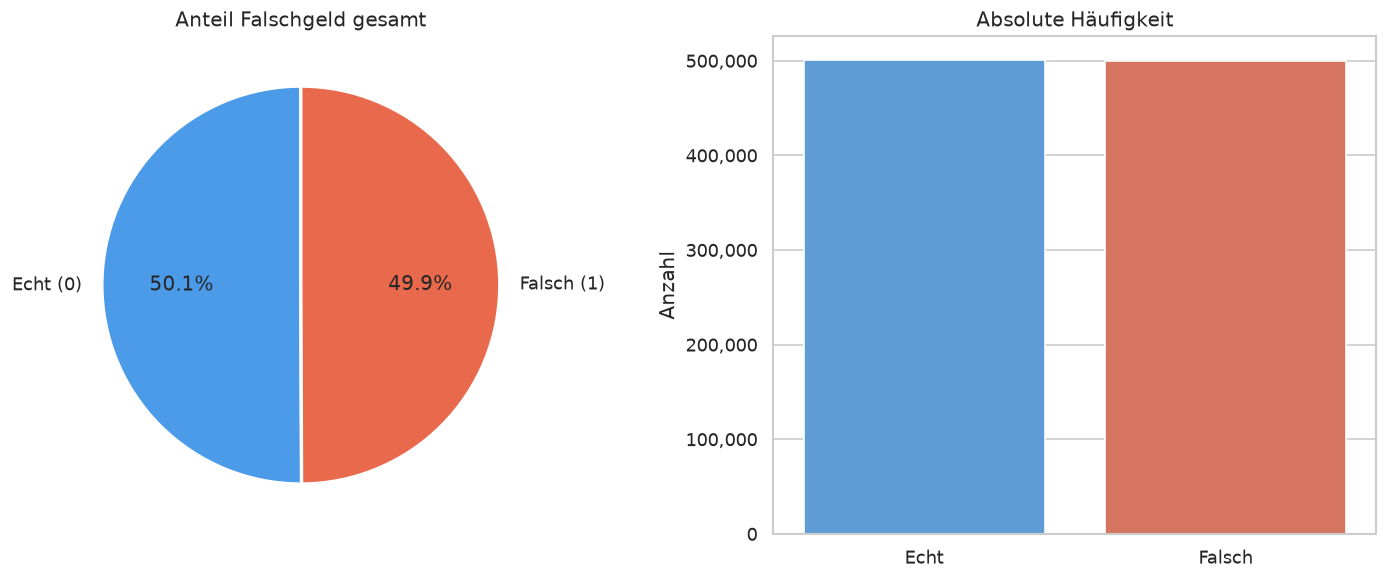

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
counts = df["Counterfeit"].value_counts().sort_index()
labels = ["Echt (0)", "Falsch (1)"]
colors = ["#4C9BE8", "#E8694C"]
axes[0].pie(counts, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Anteil Falschgeld gesamt")

# Bar
sns.countplot(data=df, x="Counterfeit", palette={"0": "#4C9BE8", "1": "#E8694C"},
              order=["0", "1"],ax=axes[1])
axes[1].set_xticklabels(["Echt", "Falsch"])
axes[1].set_xlabel("")
axes[1].set_ylabel("Anzahl")
axes[1].set_title("Absolute Häufigkeit")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

## 2 · Betrug pro Währungsraum (Country)

In [5]:
country_stats = (
    df.groupby("Country")["Counterfeit"]
    .agg(total="count", fake="sum")
    .assign(fake_rate=lambda x: x["fake"] / x["total"] * 100)
    .sort_values("fake_rate", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Absolute Anzahl (gestapelt)
country_stacked = df.groupby(["Country", "Counterfeit"]).size().unstack(fill_value=0)
country_stacked.columns = ["Echt", "Falsch"]
country_stacked.plot(kind="bar", stacked=True, color=["#4C9BE8", "#E8694C"],
                     ax=axes[0], edgecolor="white")
axes[0].set_title("Anzahl Echt vs. Falsch pro Land")
axes[0].set_xlabel("")
axes[0].set_ylabel("Anzahl")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="")

# Betrugsrate
bar_colors = ["#E8694C" if r > 50 else "#4C9BE8" for r in country_stats["fake_rate"]]
axes[1].bar(country_stats["Country"], country_stats["fake_rate"], color=bar_colors, edgecolor="white")
axes[1].axhline(50, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Betrugsrate pro Land (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Falschgeld-Anteil (%)")
axes[1].set_ylim(0, 100)

# Absolute Falschgeld-Menge
axes[2].bar(country_stats["Country"], country_stats["fake"], color="#E8694C", edgecolor="white")
axes[2].set_title("Absolute Falschgeld-Menge pro Land")
axes[2].set_xlabel("")
axes[2].set_ylabel("Anzahl Falschgeld")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

country_stats

KeyError: 'Country'

## 3 · Betrug pro Denomination (Stückelung)

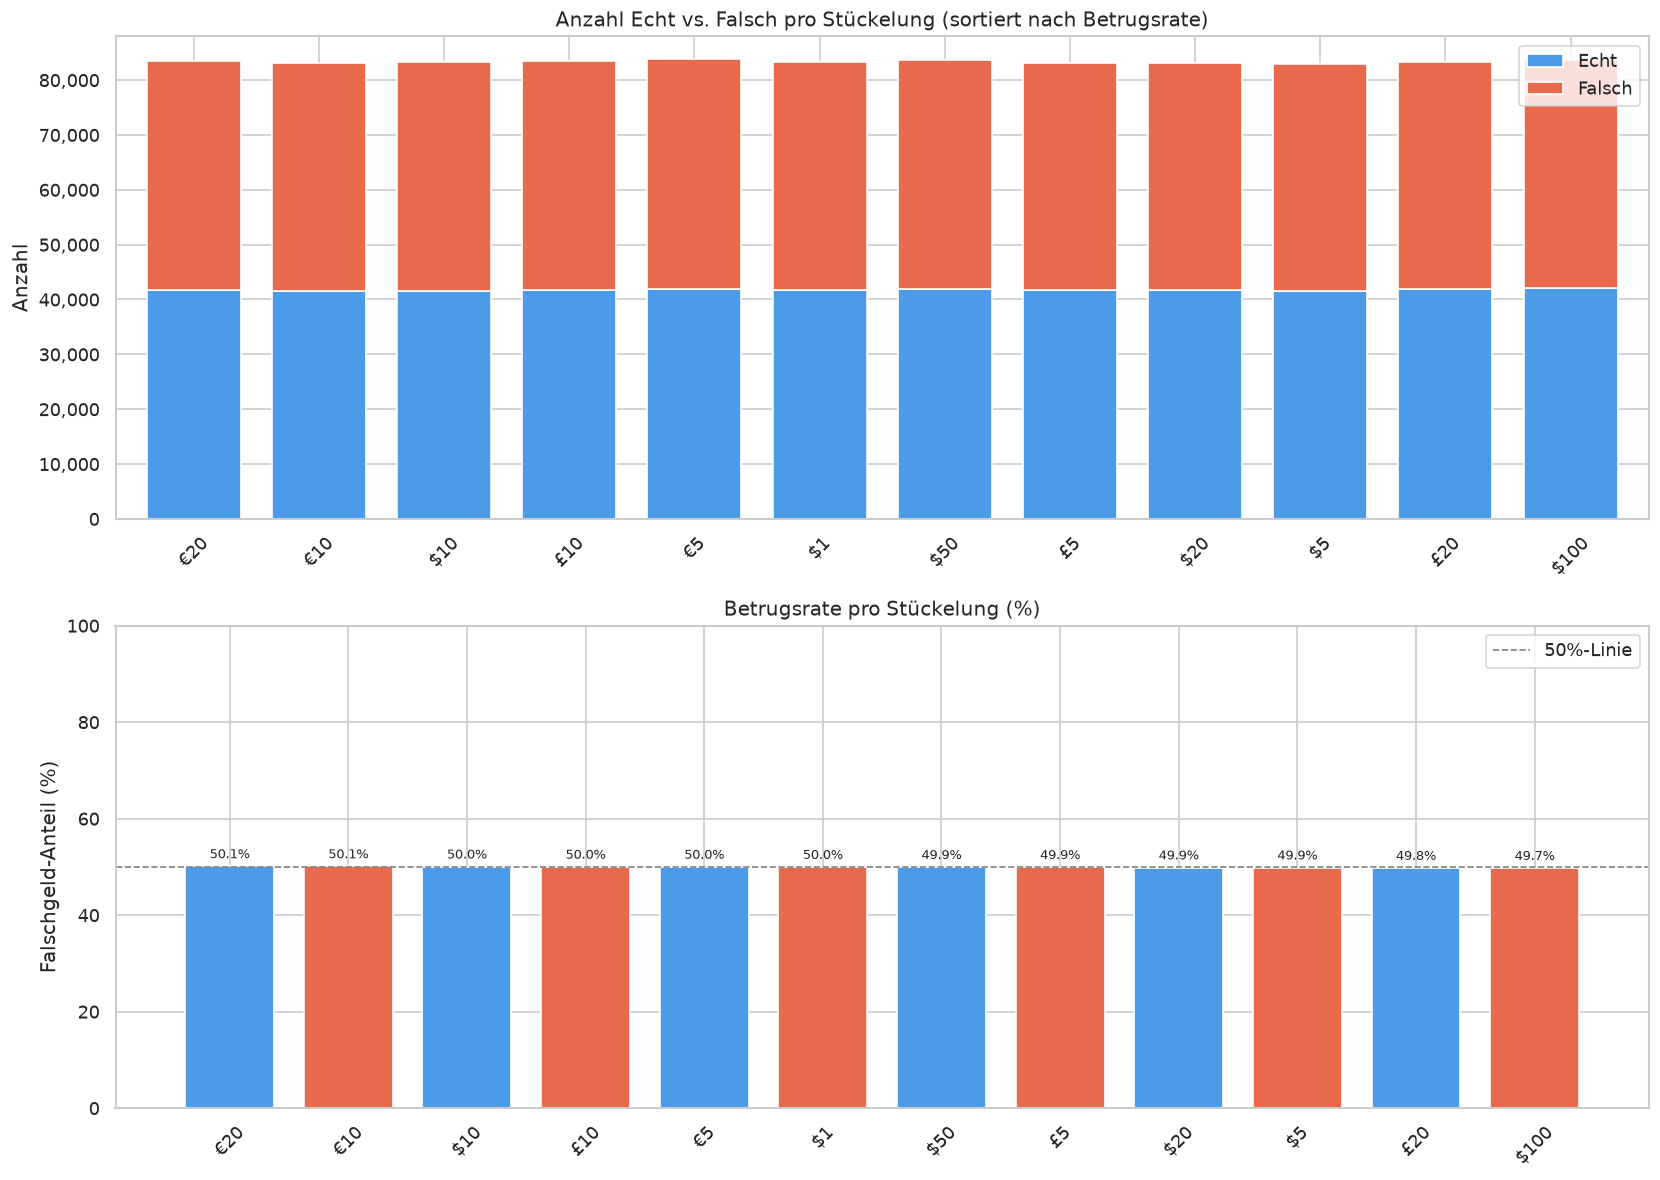

,Denomination,total,fake,fake_rate
0,€20,83494,41847,50.119769
1,€10,83159,41656,50.091992
2,$10,83232,41648,50.038447
3,£10,83432,41714,49.997603
4,€5,83769,41873,49.986272
5,$1,83346,41640,49.960406
6,$50,83593,41743,49.935999
7,£5,83192,41541,49.933888
8,$20,83061,41407,49.851314
9,$5,82868,41310,49.850364


In [ ]:
denom_stats = (
    df.groupby("Denomination")["Counterfeit"]
    .agg(total="count", fake="sum")
    .assign(fake_rate=lambda x: x["fake"] / x["total"] * 100)
    .sort_values("fake_rate", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gestapeltes Bar-Chart (Echt vs. Falsch)
denom_stacked = (
    df.groupby(["Denomination", "Counterfeit"]).size()
    .unstack(fill_value=0)
)
denom_stacked.columns = ["Echt", "Falsch"]
denom_stacked = denom_stacked.loc[denom_stats["Denomination"]]  # sortiert nach Betrugsrate
denom_stacked.plot(kind="bar", stacked=True, color=["#4C9BE8", "#E8694C"],
                   ax=axes[0], edgecolor="white", width=0.75)
axes[0].set_title("Anzahl Echt vs. Falsch pro Stückelung (sortiert nach Betrugsrate)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Anzahl")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="")

# Betrugsrate pro Denomination
bars = axes[1].bar(denom_stats["Denomination"], denom_stats["fake_rate"],
                   color=colors, edgecolor="white", width=0.75)
axes[1].axhline(50, color="gray", linestyle="--", linewidth=1, label="50%-Linie")
axes[1].set_title("Betrugsrate pro Stückelung (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Falschgeld-Anteil (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=45)
for bar, rate in zip(bars, denom_stats["fake_rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{rate:.1f}%", ha="center", va="bottom", fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.show()

denom_stats

## 4 · Sicherheitsmerkmale vs. Betrug

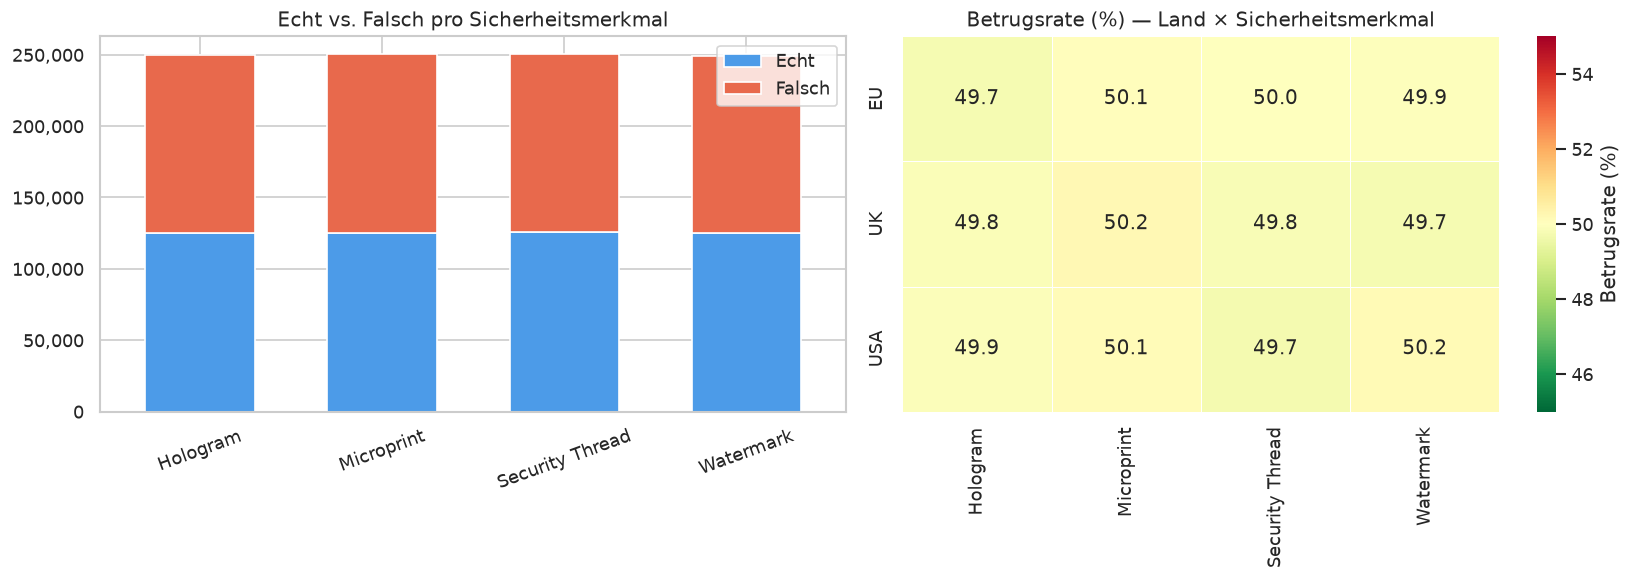

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gestapeltes Bar-Chart nach Sicherheitsmerkmal
sec_stacked = (
    df.groupby(["SecurityFeatures", "Counterfeit"]).size()
    .unstack(fill_value=0)
)
sec_stacked.columns = ["Echt", "Falsch"]
sec_stacked.plot(kind="bar", stacked=True, color=["#4C9BE8", "#E8694C"],
                 ax=axes[0], edgecolor="white", width=0.6)
axes[0].set_title("Echt vs. Falsch pro Sicherheitsmerkmal")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="")

# Heatmap: Betrugsrate Land × Sicherheitsmerkmal
heatmap_data = (
    df.groupby(["Country", "SecurityFeatures"])["Counterfeit"]
    .mean() * 100
).unstack()
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn_r",
            vmin=45, vmax=55, ax=axes[1], linewidths=0.5,
            cbar_kws={"label": "Betrugsrate (%)"})
axes[1].set_title("Betrugsrate (%) — Land × Sicherheitsmerkmal")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 5 · Physikalische Merkmale pro Denomination

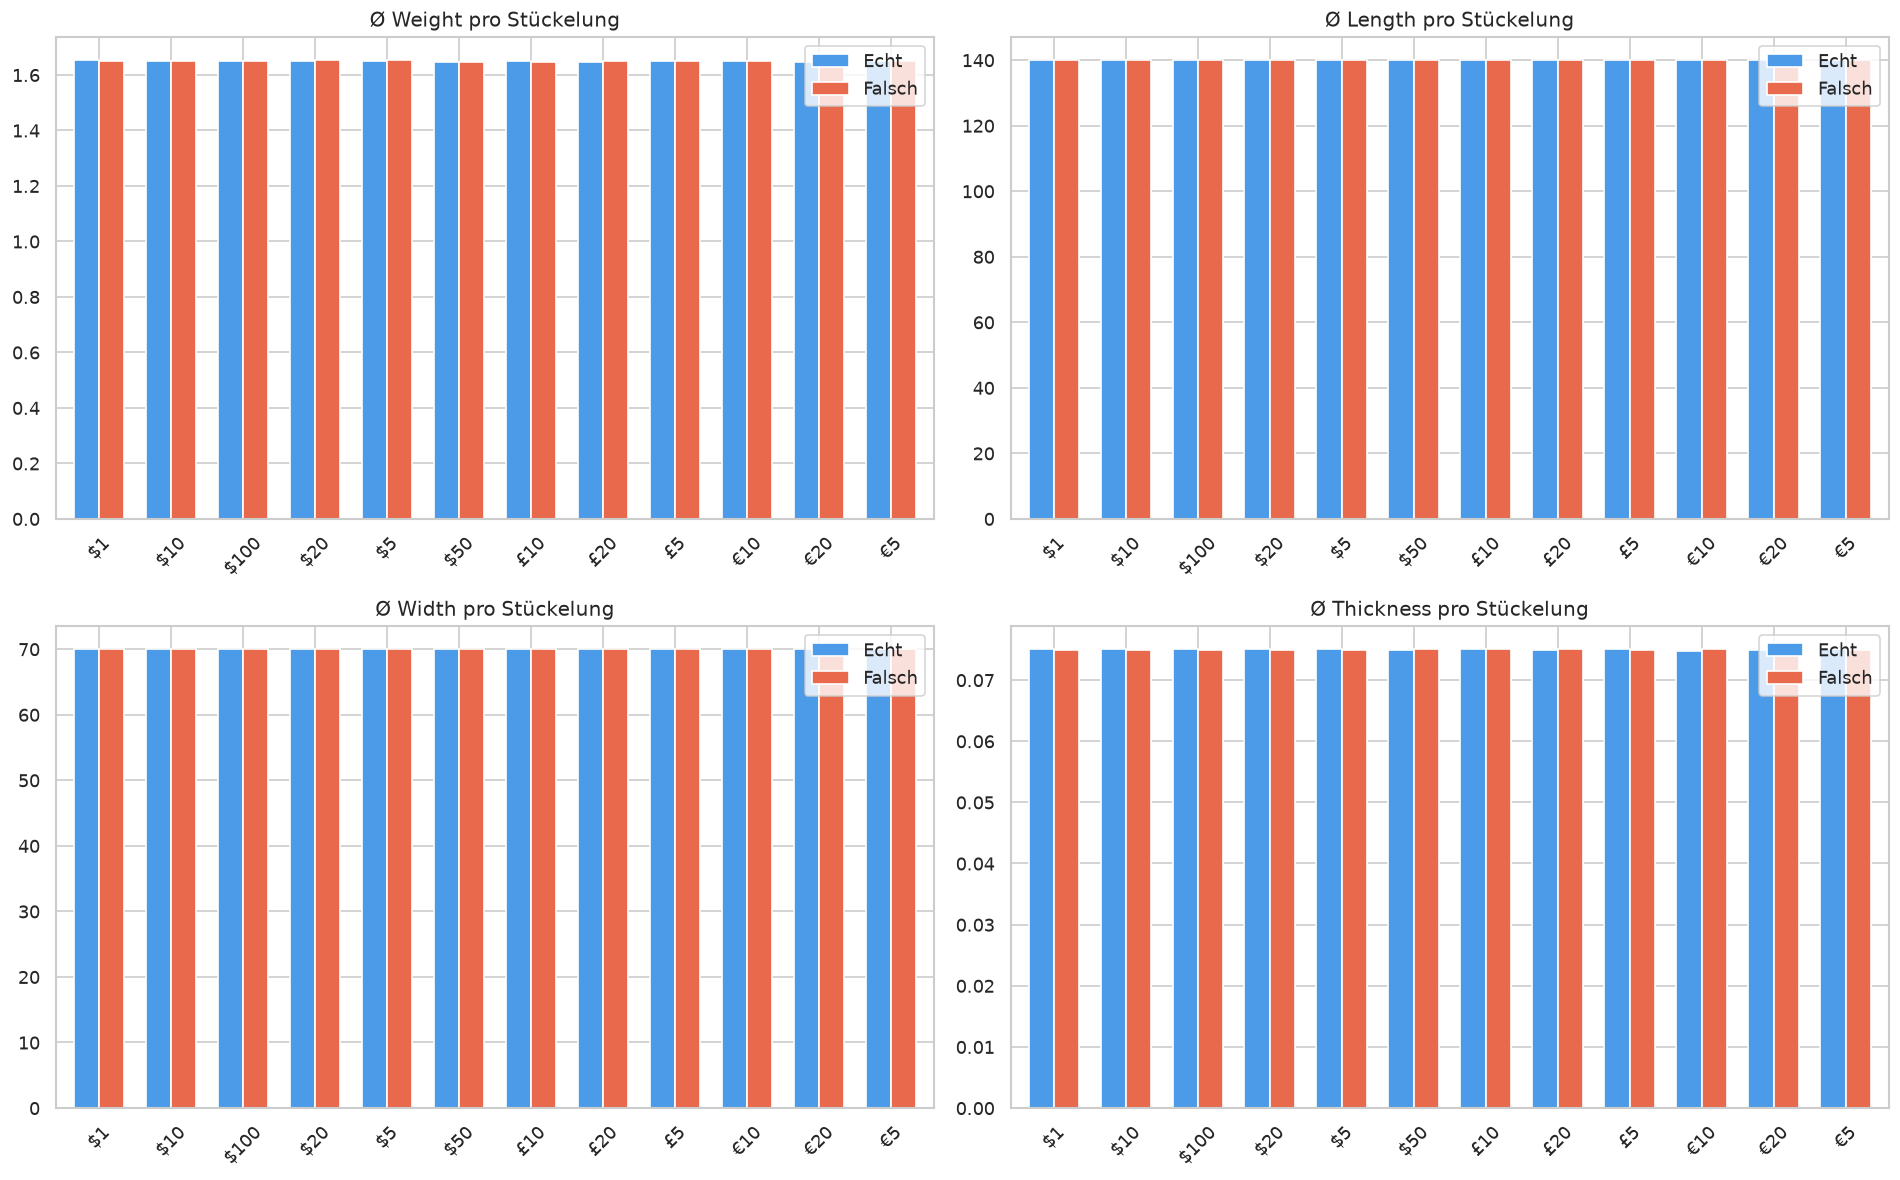

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, feat in zip(axes.flat, features):
    means = (
        df.groupby(["Denomination", "Counterfeit"])[feat]
        .mean()
        .unstack()
        .rename(columns={0: "Echt", 1: "Falsch"})
    )
    means.plot(kind="bar", ax=ax, color=["#4C9BE8", "#E8694C"],
               edgecolor="white", width=0.7)
    ax.set_title(f"Ø {feat} pro Stückelung")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="")

plt.tight_layout()
plt.show()

## 6 · Korrelationsmatrix (numerische Features)

In [ ]:
corr_matrix=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".4f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': .8}
)

ValueError: could not convert string to float: 'USA'